# Lab 3.0 — Vector Space
**Institute of Technology of Cambodia — PHAUK Sokkhey, Ph.D**

---

## Learning Objectives
By the end of this lab you will be able to:
1. Verify the **10 vector-space axioms** in NumPy.
2. Determine whether a subset is a **subspace** using the two-condition test.
3. Express a vector as a **linear combination** and check membership in a **span**.
4. Test **linear independence** via rank and determinant.
5. Identify a **basis** and compute the **dimension** of a vector space.
6. Apply these ideas to **AI (feature spaces)**, **Cybersecurity (packet vectors)**, and **Software Engineering (polynomial representations)**.

In [2]:
import numpy as np
from numpy.linalg import matrix_rank, det, lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.set_printoptions(precision=4, suppress=True)
print('Packages loaded successfully.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/monyoudom/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/monyoudom/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/monyoudom/.local/lib/python3.10

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

---
## Part 1 — Vector Space Axioms

A set $V$ with operations $+$ and scalar $\cdot$ is a **vector space** over $\mathbb{R}$ if all 10 axioms hold:

| # | Axiom | Name |
|---|-------|------|
| 1 | $\mathbf{u}+\mathbf{v} \in V$ | Closure under addition |
| 2 | $\mathbf{u}+\mathbf{v}=\mathbf{v}+\mathbf{u}$ | Commutativity |
| 3 | $(\mathbf{u}+\mathbf{v})+\mathbf{w}=\mathbf{u}+(\mathbf{v}+\mathbf{w})$ | Associativity |
| 4 | $\exists\,\mathbf{0}: \mathbf{v}+\mathbf{0}=\mathbf{v}$ | Additive identity |
| 5 | $\exists\,{-\mathbf{v}}: \mathbf{v}+(-\mathbf{v})=\mathbf{0}$ | Additive inverse |
| 6 | $\alpha\mathbf{v}\in V$ | Closure under scalar mult. |
| 7 | $\alpha(\mathbf{u}+\mathbf{v})=\alpha\mathbf{u}+\alpha\mathbf{v}$ | Distributivity (vector) |
| 8 | $(\alpha+\beta)\mathbf{v}=\alpha\mathbf{v}+\beta\mathbf{v}$ | Distributivity (scalar) |
| 9 | $(\alpha\beta)\mathbf{v}=\alpha(\beta\mathbf{v})$ | Scalar associativity |
| 10 | $1\cdot\mathbf{v}=\mathbf{v}$ | Identity scalar |

### Example 1 — Verify Axioms for $\mathbb{R}^3$

In [ ]:
u = np.array([2.0, -1.0,  5.0])
v = np.array([4.0,  3.0,  1.0])
w = np.array([-6.0, 2.0,  0.0])
alpha, beta = 3.0, -2.0

results = {
    "Axiom 2 (commutativity)":         np.allclose(u+v, v+u),
    "Axiom 3 (associativity)":         np.allclose((u+v)+w, u+(v+w)),
    "Axiom 4 (additive identity)":     np.allclose(v + np.zeros(3), v),
    "Axiom 5 (additive inverse)":      np.allclose(v + (-v), np.zeros(3)),
    "Axiom 7 (distributivity/vector)": np.allclose(alpha*(u+v), alpha*u + alpha*v),
    "Axiom 8 (distributivity/scalar)": np.allclose((alpha+beta)*v, alpha*v + beta*v),
    "Axiom 9 (scalar assoc.)":         np.allclose((alpha*beta)*v, alpha*(beta*v)),
    "Axiom 10 (identity scalar)":      np.allclose(1.0*v, v),
}

print("Vector Space Axiom Verification for R3")
print("="*45)
for name, passed in results.items():
    status = "PASS" if passed else "FAIL"
    print(f"  {status}  {name}")

Vector Space Axiom Verification for R3
  PASS  Axiom 2 (commutativity)
  PASS  Axiom 3 (associativity)
  PASS  Axiom 4 (additive identity)
  PASS  Axiom 5 (additive inverse)
  PASS  Axiom 7 (distributivity/vector)
  PASS  Axiom 8 (distributivity/scalar)
  PASS  Axiom 9 (scalar assoc.)
  PASS  Axiom 10 (identity scalar)


---
## Part 2 — Subspaces

A subset $S \subseteq V$ is a **subspace** if and only if:
1. $S \neq \emptyset$ (contains $\mathbf{0}$)
2. $\mathbf{u},\mathbf{v}\in S \Rightarrow \mathbf{u}+\mathbf{v}\in S$ (closed under addition)
3. $\mathbf{u}\in S,\,\alpha\in\mathbb{R} \Rightarrow \alpha\mathbf{u}\in S$ (closed under scalar multiplication)

### Example 2 — $W_1 = \{(x_1,x_2,x_3)\in\mathbb{R}^3 : x_1+x_2+x_3=0\}$

We verify **numerically** by sampling random vectors from $W_1$.

In [ ]:
def in_W1(v, tol=1e-9):
    """Return True if v satisfies x1+x2+x3 = 0."""
    return abs(v.sum()) < tol

# Generate vectors IN W1: pick x1,x2 freely, set x3 = -(x1+x2)
rng = np.random.default_rng(42)
a1, a2 = rng.uniform(-5, 5, 2)
u1 = np.array([a1, a2, -(a1+a2)])
b1, b2 = rng.uniform(-5, 5, 2)
u2 = np.array([b1, b2, -(b1+b2)])
alpha = 2.5

print("Subspace Test for W1 = {x in R3 : x1+x2+x3=0}")
print("="*50)
print(f"  u1 = {np.round(u1,3)}   in W1? {in_W1(u1)}")
print(f"  u2 = {np.round(u2,3)}   in W1? {in_W1(u2)}")
print()
print(f"  Cond 1 - zero vector in W1? {in_W1(np.zeros(3))}")
print(f"  Cond 2 - u1+u2 in W1?       {in_W1(u1+u2)}")
print(f"  Cond 3 - alpha*u1 in W1?    {in_W1(alpha*u1)}")

closed = in_W1(np.zeros(3)) and in_W1(u1+u2) and in_W1(alpha*u1)
print(f"W1 is {'a SUBSPACE' if closed else 'NOT a subspace'} of R3")

Subspace Test for W1 = {x in R3 : x1+x2+x3=0}
  u1 = [ 2.74  -0.611 -2.128]   in W1? True
  u2 = [ 3.586  1.974 -5.56 ]   in W1? True

  Cond 1 - zero vector in W1? True
  Cond 2 - u1+u2 in W1?       True
  Cond 3 - alpha*u1 in W1?    True
W1 is a SUBSPACE of R3


### Example 3 — $W_3 = \{(x_1,x_2,x_3)\in\mathbb{R}^3 : x_1 = x_3^2\}$ — NOT a subspace

We find a counterexample showing closure under scalar multiplication fails.

In [ ]:
def in_W3(v, tol=1e-9):
    return abs(v[0] - v[2]**2) < tol

p = np.array([1.0, 0.0, 1.0])   # 1 = 1^2, so p is in W3
alpha = -1.0
q = alpha * p                    # q = (-1, 0, -1). Check: -1 == (-1)^2 = 1? FAILS

print("Subspace Test for W3 = {x : x1 = x3^2}")
print("="*45)
print(f"  p = {p}        in W3? {in_W3(p)}")
print(f"  alpha*p = {q}   in W3? {in_W3(q)}")
print()
print("  Closure under scalar multiplication FAILS")
print("  => W3 is NOT a subspace of R3")

# Also demonstrate addition fails
p2 = np.array([4.0, 1.0, 2.0])   # 4 = 2^2, so p2 is in W3
print(f"p2 = {p2}     in W3? {in_W3(p2)}")
print(f"  p+p2 = {p+p2}  in W3? {in_W3(p+p2)}")
print("  Closure under addition also FAILS")

Subspace Test for W3 = {x : x1 = x3^2}
  p = [1. 0. 1.]        in W3? True
  alpha*p = [-1. -0. -1.]   in W3? False

  Closure under scalar multiplication FAILS
  => W3 is NOT a subspace of R3
p2 = [4. 1. 2.]     in W3? True
  p+p2 = [5. 1. 3.]  in W3? False
  Closure under addition also FAILS


### Exercise 2
Determine whether $W_2 = \{(x_1,x_2,x_3)\in\mathbb{R}^3 : x_1 = 2x_2 \text{ and } x_3 = -x_2\}$ is a subspace of $\mathbb{R}^3$.

Write a function `in_W2(v)` and test all three subspace conditions.

In [ ]:
# Exercise 2: Your code here

def in_W2(v, tol=1e-9):
    # Return True if v[0] == 2*v[1] AND v[2] == -v[1]
    pass  # YOUR CODE HERE

# Construct sample vectors (e.g. x2=t => x1=2t, x3=-t)
# YOUR CODE HERE

---
## Part 3 — Linear Combinations and Span

A vector $\mathbf{v}$ is a **linear combination** of $\mathbf{v}_1,\ldots,\mathbf{v}_p$ if there exist scalars $k_i$ such that:
$$\mathbf{v} = k_1\mathbf{v}_1 + k_2\mathbf{v}_2 + \cdots + k_p\mathbf{v}_p$$

To check: form the matrix $U = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_p]$ and solve $U\mathbf{k}=\mathbf{v}$.

### Example 4 — Express $\mathbf{v}=(10,1,4)$ as a linear combination

$\mathbf{u}_1=(2,3,5),\ \mathbf{u}_2=(1,2,4),\ \mathbf{u}_3=(-2,2,3)$

In [ ]:
u1 = np.array([2,  3, 5], dtype=float)
u2 = np.array([1,  2, 4], dtype=float)
u3 = np.array([-2, 2, 3], dtype=float)
v  = np.array([10, 1, 4], dtype=float)

U = np.column_stack([u1, u2, u3])
k, residuals, rank, _ = lstsq(U, v, rcond=None)
reconstruction = U @ k
is_lc = np.allclose(reconstruction, v)

print("Linear Combination Test: v = k1*u1 + k2*u2 + k3*u3")
print("="*50)
print(f"  Solved coefficients k = {k}")
print(f"  Reconstruction U@k   = {reconstruction}")
print(f"  Target v             = {v}")
print(f"  Reconstruction error = {np.linalg.norm(reconstruction - v):.2e}")
print(f" v IS{chr(32)+''if is_lc else ' NOT'} a linear combination of u1, u2, u3")
if is_lc:
    print(f"  v = ({k[0]:.4f})*u1 + ({k[1]:.4f})*u2 + ({k[2]:.4f})*u3")

Linear Combination Test: v = k1*u1 + k2*u2 + k3*u3
  Solved coefficients k = [ 1.  2. -3.]
  Reconstruction U@k   = [10.  1.  4.]
  Target v             = [10.  1.  4.]
  Reconstruction error = 5.33e-15
 v IS  a linear combination of u1, u2, u3
  v = (1.0000)*u1 + (2.0000)*u2 + (-3.0000)*u3


### Example 5 — AI Case Study: Is a Feature Vector in the Feature Span?

In **machine learning**, each data sample is a vector in $\mathbb{R}^n$ (the feature space).  
Checking if a new data point lies in the span of existing training vectors tells us whether it can be exactly reconstructed from known patterns — important in anomaly detection and dimensionality reduction.

> **Scenario**: Three training feature vectors are given. Can we reconstruct a new query point from them?

In [ ]:
# 3 training feature vectors in R4 (features: age, income, credit_score, risk_rank)
f1 = np.array([1.0, 0.5, 2.0, 1.0])
f2 = np.array([2.0, 1.0, 0.5, 3.0])
f3 = np.array([0.5, 2.0, 1.5, 0.5])

q1 = np.array([4.0, 2.0, 5.0, 5.0])    # should be in span (= f1+f2+2*f3 roughly)
q2 = np.array([1.0, 1.0, 1.0, 10.0])   # likely NOT in span

F = np.column_stack([f1, f2, f3])

for label, q in [("q1 (expected IN span)", q1), ("q2 (expected NOT in span)", q2)]:
    k, _, _, _ = lstsq(F, q, rcond=None)
    recon = F @ k
    in_span = np.allclose(recon, q, atol=1e-6)
    print(f"Query: {label}")
    print(f"  Coefficients     : {np.round(k,4)}")
    print(f"  Reconstruction   : {np.round(recon,4)}")
    print(f"  Target           : {q}")
    print(f"  Reconstruction error: {np.linalg.norm(recon - q):.2e}")
    print(f"  In span of training features? {'YES' if in_span else 'NO'}")
    print()

Query: q1 (expected IN span)
  Coefficients     : [ 2.2826  0.8946 -0.0163]
  Reconstruction   : [4.0637 2.0034 4.9881 4.9584]
  Target           : [4. 2. 5. 5.]
  Reconstruction error: 7.71e-02
  In span of training features? NO

Query: q2 (expected NOT in span)
  Coefficients     : [ 0.0146  2.6028 -0.7019]
  Reconstruction   : [4.8693 1.2064 0.2777 7.4721]
  Target           : [ 1.  1.  1. 10.]
  Reconstruction error: 4.68e+00
  In span of training features? NO



### Exercise 3
From Tutorial Q2: Write $\mathbf{v}$ as a linear combination of $\mathbf{u}_1, \mathbf{u}_2, \mathbf{u}_3$, if possible.

**(a)** $\mathbf{v}=(-1,7,2),\ \mathbf{u}_1=(1,3,5),\ \mathbf{u}_2=(2,-1,3),\ \mathbf{u}_3=(-3,2,-4)$

**(b)** $\mathbf{v}=(7,2,5,-3),\ \mathbf{u}_1=(2,1,1,2),\ \mathbf{u}_2=(-3,3,4,-5),\ \mathbf{u}_3=(-6,3,1,2)$

For each, print the coefficients if it is a linear combination, or state why it is not.

In [ ]:
# Exercise 3: Your code here

# (a)
v_a  = np.array([-1,  7,  2], dtype=float)
u1_a = np.array([ 1,  3,  5], dtype=float)
u2_a = np.array([ 2, -1,  3], dtype=float)
u3_a = np.array([-3,  2, -4], dtype=float)
# YOUR CODE HERE

# (b)
v_b  = np.array([ 7,  2,  5, -3], dtype=float)
u1_b = np.array([ 2,  1,  1,  2], dtype=float)
u2_b = np.array([-3,  3,  4, -5], dtype=float)
u3_b = np.array([-6,  3,  1,  2], dtype=float)
# YOUR CODE HERE

---
## Part 4 — Linear Independence

Vectors $\mathbf{v}_1,\ldots,\mathbf{v}_p$ are **linearly independent** iff
$$k_1\mathbf{v}_1+\cdots+k_p\mathbf{v}_p=\mathbf{0} \implies k_1=\cdots=k_p=0$$

**Computational approach:**
- Form matrix $A$ with the vectors as **columns**.
- If $\text{rank}(A) = p$ (number of vectors) $\Rightarrow$ **independent**.
- For square $A$: $\det(A) \neq 0 \Rightarrow$ **independent**.

### Example 6 — Independence Test: reusable function

In [4]:
def independence_test(vectors, labels=None, verbose=True):
    """Test linear independence of a list of numpy vectors."""
    A = np.column_stack(vectors)
    r = matrix_rank(A)
    n_vecs = len(vectors)
    independent = (r == n_vecs)
    if verbose:
        print("Linear Independence Test")
        print("="*45)
        if labels:
            for lbl, v in zip(labels, vectors):
                print(f"  {lbl} = {v}")
        print(f"  Rank(A)       = {r}")
        print(f"  # of vectors  = {n_vecs}")
        if A.shape[0] == A.shape[1]:
            print(f"  det(A)        = {det(A):.4f}")
        verdict = "LINEARLY INDEPENDENT" if independent else "LINEARLY DEPENDENT"
        print(f"  => Vectors are {verdict}")
        if not independent:
            print(f"     (Only {r} of {n_vecs} vectors are truly independent)")
    return independent

# From lecture Example 8: S = {(1,2,3), (0,1,2), (-2,0,1)}
print("--- Case 1: Expected INDEPENDENT ---")
independence_test(
    [np.array([1,2,3.]), np.array([0,1,2.]), np.array([-2,0,1.])],
    labels=["v1","v2","v3"]
)
print()
print("--- Case 2: Expected DEPENDENT ---")
independence_test(
    [np.array([1,2,1.]), np.array([2,4,2.]), np.array([3,6,3.])],
    labels=["v1","v2","v3"]
)

--- Case 1: Expected INDEPENDENT ---
Linear Independence Test
  v1 = [1. 2. 3.]
  v2 = [0. 1. 2.]
  v3 = [-2.  0.  1.]
  Rank(A)       = 3
  # of vectors  = 3
  det(A)        = -1.0000
  => Vectors are LINEARLY INDEPENDENT

--- Case 2: Expected DEPENDENT ---
Linear Independence Test
  v1 = [1. 2. 1.]
  v2 = [2. 4. 2.]
  v3 = [3. 6. 3.]
  Rank(A)       = 1
  # of vectors  = 3
  det(A)        = 0.0000
  => Vectors are LINEARLY DEPENDENT
     (Only 1 of 3 vectors are truly independent)


np.False_

### Example 7 — Cybersecurity Case Study: Redundant Feature Detection

In **intrusion detection systems (IDS)**, network packets are encoded as feature vectors.  
Linearly **dependent** feature vectors indicate **redundant features** — the security model contains duplicate information, which wastes memory and can mislead classifiers.

> **Goal**: Detect which packet features are redundant so we can reduce the feature space.

In [ ]:
# Packet feature vectors: [pkt_size, ttl, port_flag, payload_entropy]
pkt1 = np.array([1.0, 0.0, 1.0, 0.5])   # normal traffic
pkt2 = np.array([0.0, 1.0, 0.0, 0.8])   # suspicious traffic
pkt3 = np.array([2.0, 1.0, 2.0, 1.8])   # = 2*pkt1 + pkt2 --> REDUNDANT

print("Cybersecurity -- Packet Feature Redundancy Analysis")
print("="*55)
ind = independence_test([pkt1, pkt2, pkt3], labels=["pkt1","pkt2","pkt3"])
print()
if not ind:
    k, _, _, _ = lstsq(np.column_stack([pkt1, pkt2]), pkt3, rcond=None)
    print(f"  Interpretation: pkt3 is a linear combination of pkt1 and pkt2")
    print(f"  pkt3 = {k[0]:.2f}*pkt1 + {k[1]:.2f}*pkt2")
    print(f"  Action: Remove pkt3 from feature matrix to reduce dimensionality")

Cybersecurity -- Packet Feature Redundancy Analysis
Linear Independence Test
  pkt1 = [1.  0.  1.  0.5]
  pkt2 = [0.  1.  0.  0.8]
  pkt3 = [2.  1.  2.  1.8]
  Rank(A)       = 2
  # of vectors  = 3
  => Vectors are LINEARLY DEPENDENT
     (Only 2 of 3 vectors are truly independent)

  Interpretation: pkt3 is a linear combination of pkt1 and pkt2
  pkt3 = 2.00*pkt1 + 1.00*pkt2
  Action: Remove pkt3 from feature matrix to reduce dimensionality


### Exercise 4
From Tutorial Q4, determine whether the following are linearly independent.

**(a)** $(1,1,0),\ (2,1,0),\ (2,3,4)$ in $\mathbb{R}^3$

**(b)** $(1,1,-1,2),\ (1,2,1,1),\ (2,1,2,3)$ in $\mathbb{R}^4$

Use `independence_test()`. Also write a comment explaining the **geometric meaning** of your result (e.g., do the vectors span a plane, a line, or all of $\mathbb{R}^3$?).

Vectors $\mathbf{v}_1,\ldots,\mathbf{v}_p$ are **linearly independent** iff
$$k_1\mathbf{v}_1+\cdots+k_p\mathbf{v}_p=\mathbf{0} \implies k_1=\cdots=k_p=0$$

**Computational approach:**
- Form matrix $A$ with the vectors as **columns**.
- If $\text{rank}(A) = p$ (number of vectors) $\Rightarrow$ **independent**.
- For square $A$: $\det(A) \neq 0 \Rightarrow$ **independent**.


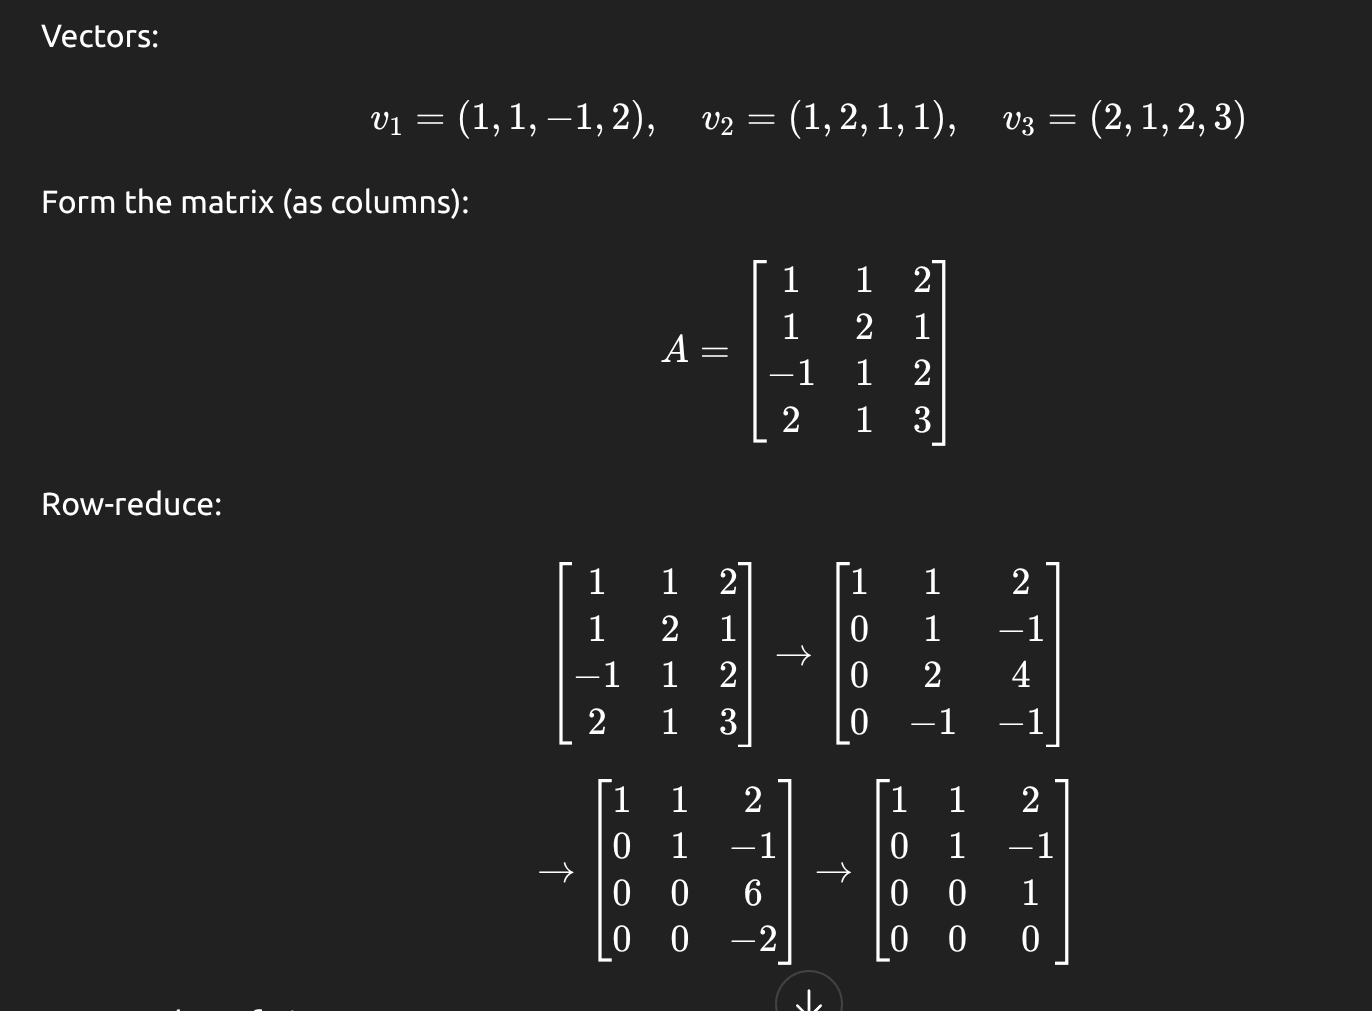

In [8]:
#part a

# Exercise 4(a) — Three vectors in R³
print("--- Exercise 4(a): Vectors in R³ ---")
independence_test(
    [np.array([1, 1, 0.]), np.array([2, 1, 0.]), np.array([2, 3, 4.])],
    labels=["v1", "v2", "v3"]
)
# Geometric meaning:
# rank = 3 = number of vectors = dimension of R³
# => These 3 vectors are LINEARLY INDEPENDENT.
# => det(A) ≠ 0 confirms the matrix is invertible.
# => They form a BASIS for R³ — they span ALL of R³.
# => Any point (x, y, z) in 3D space can be written as
#    c1*v1 + c2*v2 + c3*v3 for some scalars c1, c2, c3.
# => Geometrically: like having 3 arrows pointing in truly
#    different directions — together they fill all of 3D space.

# ===== Part (b) =====
print()
print("--- Exercise 4 (b) ---")
independence_test(
    [
        np.array([1, 1, -1, 2.]),
        np.array([1, 2,  1, 1.]),
        np.array([2, 1,  2, 3.])
    ],
    labels=["v1", "v2", "v3"]
)

--- Exercise 4(a): Vectors in R³ ---
Linear Independence Test
  v1 = [1. 1. 0.]
  v2 = [2. 1. 0.]
  v3 = [2. 3. 4.]
  Rank(A)       = 3
  # of vectors  = 3
  det(A)        = -4.0000
  => Vectors are LINEARLY INDEPENDENT

--- Exercise 4 (b) ---
Linear Independence Test
  v1 = [ 1.  1. -1.  2.]
  v2 = [1. 2. 1. 1.]
  v3 = [2. 1. 2. 3.]
  Rank(A)       = 3
  # of vectors  = 3
  => Vectors are LINEARLY INDEPENDENT


np.True_

---
## Part 5 — Basis and Dimension

A set $B = \{\mathbf{v}_1,\ldots,\mathbf{v}_n\}$ is a **basis** for $V$ if:
1. The vectors are **linearly independent**.
2. $\text{Span}(B) = V$.

The **dimension** $\dim V = n$ (number of basis vectors).

**Key facts (Theorems 4 & 5 from lecture):**
- The standard basis for $\mathbb{R}^n$ has exactly $n$ vectors.
- Any basis for $V$ has exactly $\dim V$ vectors.
- Too few vectors: can't span. Too many: must be dependent.
- To find a basis for $\text{Col}(A)$: identify the **pivot columns**.

### Example 8 — Find a Basis for the Column Space of $A$

In [ ]:
A = np.array([
    [1,  3,  1,  4],
    [2,  7,  3,  9],
    [1,  5,  3,  1],
    [1,  2,  0,  8]
], dtype=float)

r = matrix_rank(A)
print("Matrix A:")
print(A)
print(f"Rank(A) = {r}  =>  dim(Col(A)) = {r}")

# Find pivot columns (greedy: add col if it increases rank)
pivot_cols = []
for j in range(A.shape[1]):
    candidate = pivot_cols + [j]
    if matrix_rank(A[:, candidate]) > len(pivot_cols):
        pivot_cols.append(j)
    if len(pivot_cols) == r:
        break

print(f" Pivot (basis) column indices: {pivot_cols}")
print(f" Basis for Col(A):")
for i, col in enumerate(pivot_cols):
    print(f"  b{i+1} = A[:,{col}] = {A[:,col]}")
print(f" dim(Col(A)) = {len(pivot_cols)}")

Matrix A:
[[1. 3. 1. 4.]
 [2. 7. 3. 9.]
 [1. 5. 3. 1.]
 [1. 2. 0. 8.]]
Rank(A) = 3  =>  dim(Col(A)) = 3
 Pivot (basis) column indices: [0, 1, 3]
 Basis for Col(A):
  b1 = A[:,0] = [1. 2. 1. 1.]
  b2 = A[:,1] = [3. 7. 5. 2.]
  b3 = A[:,3] = [4. 9. 1. 8.]
 dim(Col(A)) = 3


### Example 9 — Software Engineering Case Study: Polynomial Representations

In **computer graphics** and **curve fitting**, functions are represented as polynomials in $P_2 = \{a + bx + cx^2\}$.  
The standard basis is $\{1, x, x^2\}$ with dimension 3.

> **Scenario**: Do these three polynomials form a basis for $P_2$?  
> $p_1 = 1+2x+x^2,\quad p_2 = 3+x^2,\quad p_3 = x+x^2$

In [ ]:
# Represent each polynomial p = a + bx + cx^2 as coefficient vector [a, b, c]
p1 = np.array([1, 2, 1], dtype=float)   # 1 + 2x + x^2
p2 = np.array([3, 0, 1], dtype=float)   # 3 + x^2
p3 = np.array([0, 1, 1], dtype=float)   # x + x^2

P = np.column_stack([p1, p2, p3])
r = matrix_rank(P)
d = det(P)

print("Polynomial Basis Test for P2")
print("="*40)
print(f"  p1 = [1,2,1]  (1 + 2x + x^2)")
print(f"  p2 = [3,0,1]  (3 + x^2)")
print(f"  p3 = [0,1,1]  (x + x^2)")
print(f" Coefficient matrix P:")
print(P)
print(f" Rank = {r},  det = {d:.4f}")
print(f"  dim(P2) = 3, need rank = 3")
print(f" => {chr(123)}p1,p2,p3{chr(125)} {'FORMS a BASIS for P2' if r==3 else 'does NOT form a basis for P2'}")

Polynomial Basis Test for P2
  p1 = [1,2,1]  (1 + 2x + x^2)
  p2 = [3,0,1]  (3 + x^2)
  p3 = [0,1,1]  (x + x^2)
 Coefficient matrix P:
[[1. 3. 0.]
 [2. 0. 1.]
 [1. 1. 1.]]
 Rank = 3,  det = -4.0000
  dim(P2) = 3, need rank = 3
 => {p1,p2,p3} FORMS a BASIS for P2


### Exercise 5
From Tutorial Q7, determine whether the following sets are bases for the stated space.

**(a)** $\{(1,-1,2),\ (2,1,0),\ (2,3,4)\}$ — basis for $\mathbb{R}^3$?

**(b)** $\{(1,1,-1,1),\ (2,3,-1,2),\ (3,1,-2,1),\ (1,2,-1,3)\}$ — basis for $\mathbb{R}^4$?

**(c)** $\{1+2x+x^2,\ 3+x^2,\ x+x^2\}$ — basis for $P_2$?

Print rank, determinant (where applicable), and a clear YES/NO with justification.

In [ ]:
# Exercise 5: Your code here

# (a) R3
# YOUR CODE HERE

# (b) R4
# YOUR CODE HERE

# (c) P2 -- represent each polynomial as [a, b, c] coefficient vector
# YOUR CODE HERE

---
## Part 6 — Visualization

### Example 10 — Span of Two Vectors in $\mathbb{R}^3$

The span of two linearly **independent** vectors in $\mathbb{R}^3$ is a **plane**.  
The span of two linearly **dependent** vectors is a **line**.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": "3d"})

for ax, case in zip(axes, ["independent", "dependent"]):
    if case == "independent":
        v1, v2 = np.array([1,0,0]), np.array([0,1,0])
        title = "Independent vectors => Span = Plane"
        color = "steelblue"
    else:
        v1, v2 = np.array([1,1,1]), np.array([2,2,2])
        title = "Dependent vectors => Span = Line"
        color = "crimson"

    origin = [0,0,0]
    ax.quiver(*origin, *v1, color=color, linewidth=2.5, arrow_length_ratio=0.15, label="v1")
    ax.quiver(*origin, *v2, color="darkorange", linewidth=2.5, arrow_length_ratio=0.15, label="v2")

    t = np.linspace(-2, 2, 6)
    if case == "independent":
        s, tt = np.meshgrid(t, t)
        X = s*v1[0] + tt*v2[0]
        Y = s*v1[1] + tt*v2[1]
        Z = s*v1[2] + tt*v2[2]
        ax.plot_surface(X, Y, Z, alpha=0.2, color=color)
    else:
        line = np.outer(t, v1)
        ax.plot(line[:,0], line[:,1], line[:,2], color=color, linewidth=2, alpha=0.6)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_zlim(-2,2)
    ax.legend()

plt.suptitle("Span Visualization: Independent vs Dependent Vectors", fontsize=13)
plt.tight_layout()
plt.show()

### Exercise 6 (Visualization)
Plot the three standard basis vectors $\mathbf{e}_1=(1,0,0),\ \mathbf{e}_2=(0,1,0),\ \mathbf{e}_3=(0,0,1)$ in a single 3D plot using `ax.quiver`. Use three different colors (red, green, blue) and label them.

In [ ]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

e1 = np.array([1, 0, 0])
e2 = np.array([0, 1, 0])
e3 = np.array([0, 0, 1])

# YOUR CODE HERE -- plot each basis vector with a different color
# Label them e1, e2, e3

plt.title("Standard Basis of R3")
plt.show()

---
## Challenge Problems

### Challenge 1 — Full Pipeline (AI: Anomaly Detection Context)

Given 5 network log feature vectors in $\mathbb{R}^4$, perform the complete vector-space analysis:

In [ ]:
logs = np.array([
    [2,  1, -1,  3],
    [1, -2,  4,  1],
    [4, -3,  7,  5],   # possibly dependent on others
    [0,  3, -5,  1],
    [1,  1,  1,  1],
], dtype=float)

print("Network Log Feature Matrix (rows = samples, cols = features)")
print(logs)

# Step 1: Rank & dimension of the span
A = logs.T   # each column is a sample
r = matrix_rank(A)
print(f"
Step 1: Rank of sample matrix = {r}")
print(f"        Dimension of span = {r} (out of 4 possible)")

# Step 2: Are all 5 samples linearly independent?
print(f"
Step 2: All 5 samples independent? {'YES' if r==5 else 'NO -- some are redundant'}")

# Step 3: Find a basis (maximal independent subset of logs)
pivot_cols = []
for j in range(A.shape[1]):
    candidate = pivot_cols + [j]
    if matrix_rank(A[:, candidate]) > len(pivot_cols):
        pivot_cols.append(j)
    if len(pivot_cols) == r:
        break

print(f"
Step 3: Basis sample indices: {pivot_cols}")
for i in pivot_cols:
    print(f"         log[{i}] = {logs[i]}")

# Step 4: Is log[2] in the span of the basis?
basis_matrix = logs[pivot_cols].T
target = logs[2]
k, _, _, _ = lstsq(basis_matrix, target, rcond=None)
recon = basis_matrix @ k
print(f"
Step 4: Is log[2] in span of basis samples?")
print(f"        Reconstruction error = {np.linalg.norm(recon - target):.2e}")
print(f"        Answer: {'YES (redundant sample)' if np.allclose(recon, target) else 'NO (new information)'}")

### Challenge 2 — Subspace or Not?

For each set, determine **analytically** (write your reasoning as a comment) and **verify numerically** whether it is a subspace of $\mathbb{R}^3$.

| Set | Definition |
|-----|------------|
| $W_a$ | $\{(x_1,x_2,x_3): x_1+x_2+x_3=0\}$ |
| $W_b$ | $\{(x_1,x_2,x_3): x_1^2 + x_2^2 = x_3^2\}$ (cone) |
| $W_c$ | $\{(x_1,x_2,x_3): x_1=1\}$ (affine plane) |

In [ ]:
# Challenge 2: Your code here
# Tip: for Wb use a Pythagorean triple like (3,4,5) to get vectors in Wb

# Wa: x1+x2+x3=0
# Analytical reason (comment): ...
# YOUR CODE HERE

# Wb: x1^2 + x2^2 = x3^2
# Analytical reason (comment): ...
# YOUR CODE HERE

# Wc: x1 = 1
# Analytical reason (comment): ...
# YOUR CODE HERE

### Challenge 3 — Basis for a Subspace (Tutorial Q6 extended)

Given $S = \{(6,4,1),\ (3,-5,1),\ (8,13,6),\ (0,6,9)\}$ in $\mathbb{R}^3$:
1. Explain **why $S$ cannot be a basis** for $\mathbb{R}^3$.
2. Find a **maximal linearly independent subset** of $S$.
3. What is the **dimension** of $\text{Span}(S)$?

In [ ]:
S = np.array([
    [6,  4,  1],
    [3, -5,  1],
    [8, 13,  6],
    [0,  6,  9]
], dtype=float)

# Step 1: Why can S not be a basis for R3?
# A basis for R3 must have exactly 3 vectors (dim R3 = 3).
# S has 4 vectors, so by Theorem 5 it cannot be a basis.
print("Step 1: S has", len(S), "vectors but dim(R3) = 3 => cannot be a basis")

# Step 2: Find maximal independent subset
# YOUR CODE HERE

# Step 3: What is dim(Span(S))?
# YOUR CODE HERE

---
## Summary Table

| Concept | How to check in NumPy | Key function |
|---------|----------------------|--------------|
| Vector space axioms | Verify elementwise equalities | `np.allclose` |
| Subspace | Check zero vector, closure under $+$ and $\cdot$ | Custom `in_W` function |
| Linear combination | Solve $U\mathbf{k}=\mathbf{v}$ | `lstsq` |
| Span membership | `np.allclose(U@k, v)` after `lstsq` | `lstsq` + `allclose` |
| Linear independence | `rank(A) == p` (number of vectors) | `matrix_rank` |
| Basis | Independent + spans $V$ | `matrix_rank` + pivot selection |
| Dimension | `rank` of the spanning matrix | `matrix_rank` |

---
*Lab 3.0 — Linear Algebra | ITC | PHAUK Sokkhey, Ph.D*